In [5]:
import os
import glob
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

# ==========================================
# PHẦN 1: HUẤN LUYỆN MÔ HÌNH (TRAINING)
# ==========================================

def train_smart_cushion_model(data_folder='./data', model_path='smart_cushion_model.h5', scaler_path='fsr_scaler.pkl'):
    print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---")
    
    # 1. TÌM TẤT CẢ FILE EXCEL TRONG THƯ MỤC
    file_pattern = os.path.join(data_folder, "*.xlsx")
    all_files = glob.glob(file_pattern)
    
    if not all_files:
        print(f"Lỗi: Không tìm thấy file Excel (.xlsx) nào trong thư mục '{data_folder}'.")
        return None, None

    # 9 cột cảm biến theo ma trận 3x3
    fsr_cols = [
        'FSR Front Left', 'FSR Front Mid', 'FSR Front Right',
        'FSR Mid Left', 'FSR Mid Mid', 'FSR Mid Right',
        'FSR Back Left', 'FSR Back Mid', 'FSR Back Right'
    ]

    scaler = MinMaxScaler()
    all_valid_data = pd.DataFrame()

    # Bước 1: Đọc và làm sạch dữ liệu từ các file Excel
    print("Đang đọc và làm sạch dữ liệu từ Excel...")
    for file_path in all_files:
        try:
            # Đọc file Excel bằng engine openpyxl
            df = pd.read_excel(file_path)
            
            # Chỉ lấy dữ liệu khi có người ngồi
            df_valid = df[df['Person Present'] == 1].copy()
            
            if not df_valid.empty:
                # Gán nhãn dựa vào tên file
                filename = os.path.basename(file_path)
                label = 1 if "Sitting_straight" in filename else 0
                df_valid['Label_Target'] = label
                all_valid_data = pd.concat([all_valid_data, df_valid], ignore_index=True)
                print(f"  + Đã nạp: {filename} (Nhãn: {'Đúng' if label==1 else 'Sai'})")
        except Exception as e:
            print(f"  - Lỗi khi đọc file {os.path.basename(file_path)}: {e}")

    if all_valid_data.empty:
        print("Không có dữ liệu hợp lệ (Person Present = 1) để huấn luyện.")
        return None, None

    # Bước 2: Chuẩn hóa (MinMaxScaler) và Reshape
    X_scaled = scaler.fit_transform(all_valid_data[fsr_cols])
    joblib.dump(scaler, scaler_path)
    print(f"Đã lưu bộ chuẩn hóa Scaler tại: {scaler_path}")
    
    # Reshape sang 3x3x1 cho 2D-CNN
    X = X_scaled.reshape(-1, 3, 3, 1)
    y = all_valid_data['Label_Target'].values

    # Bước 3: Chia tập dữ liệu (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Bước 4: Xây dựng và Compile kiến trúc CNN
    model = models.Sequential([
        layers.Conv2D(16, (2, 2), activation='relu', padding='same', input_shape=(3, 3, 1)),
        layers.Conv2D(32, (2, 2), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Bước 5: Huấn luyện
    print("\nĐang huấn luyện mạng Deep Learning...")
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)

    # Đánh giá
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n=> Độ chính xác trên tập Test: {accuracy*100:.2f}%")

    # Lưu model
    model.save(model_path)
    print(f"Đã lưu mô hình tại: {model_path}\n")
    
    return model, scaler


# ==========================================
# PHẦN 2: DỰ ĐOÁN VÀ ĐÓNG GÓI OUTPUT (INFERENCE)
# ==========================================

def predict_posture(raw_fsr_values, model_path='smart_cushion_model.h5', scaler_path='fsr_scaler.pkl'):
    """
    Hàm nhận 9 giá trị cảm biến, dự đoán và trả về JSON chuẩn hóa.
    raw_fsr_values: List gồm 9 giá trị nguyên [FL, FM, FR, ML, MM, MR, BL, BM, BR]
    """
    try:
        model = load_model(model_path)
        scaler = joblib.load(scaler_path)
    except Exception as e:
        return {"error": f"Không thể load model hoặc scaler: {str(e)}"}

    input_df = pd.DataFrame([raw_fsr_values], columns=[
        'FSR Front Left', 'FSR Front Mid', 'FSR Front Right',
        'FSR Mid Left', 'FSR Mid Mid', 'FSR Mid Right',
        'FSR Back Left', 'FSR Back Mid', 'FSR Back Right'
    ])
    
    scaled_values = scaler.transform(input_df)
    cnn_input = scaled_values.reshape(1, 3, 3, 1)
    
    prediction_score = model.predict(cnn_input, verbose=0)[0][0]
    
    is_correct = prediction_score > 0.5
    status = "Sitting Straight" if is_correct else "Incorrect/Leaning"
    confidence = float(prediction_score if is_correct else (1 - prediction_score))
    
    result = {
        "sensors_input": {
            "front_row": {"left": raw_fsr_values[0], "mid": raw_fsr_values[1], "right": raw_fsr_values[2]},
            "mid_row":   {"left": raw_fsr_values[3], "mid": raw_fsr_values[4], "right": raw_fsr_values[5]},
            "back_row":  {"left": raw_fsr_values[6], "mid": raw_fsr_values[7], "right": raw_fsr_values[8]}
        },
        "ai_prediction": {
            "posture_status": status,
            "confidence_level": round(confidence, 4),
            "raw_score": round(float(prediction_score), 4)
        }
    }
    
    return result

# ==========================================
# CHẠY THỬ NGHIỆM TỔNG THỂ
# ==========================================
if __name__ == "__main__":
    trained_model, used_scaler = train_smart_cushion_model(data_folder='./data')
    
    if trained_model is not None:
        print("--- THỬ NGHIỆM DỰ ĐOÁN REAL-TIME ---")
        # Giả lập 9 thông số cảm biến (ví dụ 1 dòng dữ liệu ngồi đúng)
        sample_sensor_data = [1534, 0, 3663, 4035, 2355, 4036, 3179, 3743, 2275] 
        
        final_output = predict_posture(sample_sensor_data)
        print(json.dumps(final_output, indent=4, ensure_ascii=False))

--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---
Đang đọc và làm sạch dữ liệu từ Excel...
  + Đã nạp: cushion_data_Leaning_right_20260419_175910.xlsx (Nhãn: Sai)
  + Đã nạp: cushion_data_Sitting_straight_20260419_172423.xlsx (Nhãn: Đúng)
Đã lưu bộ chuẩn hóa Scaler tại: fsr_scaler.pkl


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Đang huấn luyện mạng Deep Learning...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7778 - loss: 0.5244 - val_accuracy: 0.6744 - val_loss: 0.6254
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7778 - loss: 0.4554 - val_accuracy: 0.6744 - val_loss: 0.5262
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7807 - loss: 0.3954 - val_accuracy: 0.6744 - val_loss: 0.4234
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8099 - loss: 0.3102 - val_accuracy: 0.8372 - val_loss: 0.3048
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9766 - loss: 0.2097 - val_accuracy: 1.0000 - val_loss: 0.1764
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9825 - loss: 0.1224 - val_accuracy: 1.0000 - val_loss: 0.0817
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9942 - loss: 0.0696 - val_accuracy: 1.0000 - val_loss: 0.0421
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9942 - 


=> Độ chính xác trên tập Test: 100.00%
Đã lưu mô hình tại: smart_cushion_model.h5

--- THỬ NGHIỆM DỰ ĐOÁN REAL-TIME ---


{
    "sensors_input": {
        "front_row": {
            "left": 1534,
            "mid": 0,
            "right": 3663
        },
        "mid_row": {
            "left": 4035,
            "mid": 2355,
            "right": 4036
        },
        "back_row": {
            "left": 3179,
            "mid": 3743,
            "right": 2275
        }
    },
    "ai_prediction": {
        "posture_status": "Sitting Straight",
        "confidence_level": 1.0,
        "raw_score": 1.0
    }
}


In [6]:
sample_sensor_data = [1134, 0, 3663, 4035, 2355, 4036, 3179, 3743, 2275] 
        
final_output = predict_posture(sample_sensor_data)
print(json.dumps(final_output, indent=4, ensure_ascii=False))

{
    "sensors_input": {
        "front_row": {
            "left": 1134,
            "mid": 0,
            "right": 3663
        },
        "mid_row": {
            "left": 4035,
            "mid": 2355,
            "right": 4036
        },
        "back_row": {
            "left": 3179,
            "mid": 3743,
            "right": 2275
        }
    },
    "ai_prediction": {
        "posture_status": "Sitting Straight",
        "confidence_level": 0.9999,
        "raw_score": 0.9999
    }
}


--- HUẤN LUYỆN MÔ HÌNH 9 TƯ THẾ ---
  + Đã nạp: cushion_data_clll_20260423_182505.xlsx -> Gán Class: 8
  + Đã nạp: cushion_data_clll_20260423_182952.xlsx -> Gán Class: 8
  + Đã nạp: cushion_data_cll_20260423_180908.xlsx -> Gán Class: 6
  + Đã nạp: cushion_data_cll_20260423_181230.xlsx -> Gán Class: 6
  + Đã nạp: cushion_data_crll_20260423_181629.xlsx -> Gán Class: 7
  + Đã nạp: cushion_data_crll_20260423_181952.xlsx -> Gán Class: 7
  + Đã nạp: cushion_data_crl_20260423_180008.xlsx -> Gán Class: 5
  + Đã nạp: cushion_data_crl_20260423_180507.xlsx -> Gán Class: 5
  + Đã nạp: cushion_data_lb_20260423_175125.xlsx -> Gán Class: 2
  + Đã nạp: cushion_data_lb_20260423_175458.xlsx -> Gán Class: 2
  + Đã nạp: cushion_data_lfsl_20260423_173554.xlsx -> Gán Class: 4
  + Đã nạp: cushion_data_lfsl_20260423_173954.xlsx -> Gán Class: 4
  + Đã nạp: cushion_data_lfsr_20260423_172354.xlsx -> Gán Class: 3
  + Đã nạp: cushion_data_lfsr_20260423_173036.xlsx -> Gán Class: 3
  + Đã nạp: cushion_data_lf_202604

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7502 - loss: 0.5890 - val_accuracy: 0.9114 - val_loss: 0.2064
Epoch 2/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9195 - loss: 0.1691 - val_accuracy: 0.9295 - val_loss: 0.1239
Epoch 3/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9379 - loss: 0.1219 - val_accuracy: 0.9702 - val_loss: 0.1010
Epoch 4/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9517 - loss: 0.1014 - val_accuracy: 0.9760 - val_loss: 0.0867
Epoch 5/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9577 - loss: 0.0964 - val_accuracy: 0.9629 - val_loss: 0.0933
Epoch 6/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9618 - loss: 0.0865 - val_accuracy: 0.9625 - val_loss: 0.0693
Epoch 7/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9723 - loss: 0.0747 - val_accuracy: 0.9797 - val_loss: 0.0591
Epoch 8/300
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9759 - loss: 0.0622 - val_accuracy: 0.9530

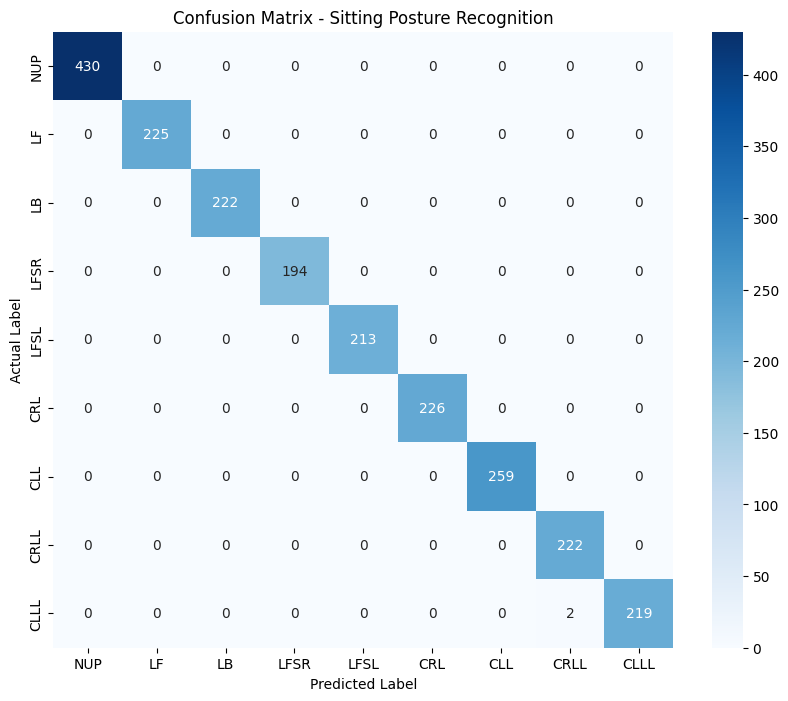


--- ĐÃ LƯU MÔ HÌNH VÀ KẾT THÚC ---


NameError: name 'history' is not defined

In [9]:
import os
import glob
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Cấu trúc từ điển để giải thích output
POSTURE_INFO = {
    0: {"label": "NUP", "name": "Tư thế thẳng tự nhiên", "desc": "Cột sống thẳng, cân bằng."},
    1: {"label": "LF",  "name": "Tư thế cúi về trước", "desc": "Thân người đổ về trước."},
    2: {"label": "LB",  "name": "Tư thế ngả về sau", "desc": "Thân người ngả ra sau."},
    3: {"label": "LFSR", "name": "Tựa đầu/khuỷu tay phải", "desc": "Đổ người, tựa đầu vào tay trên bàn bên phải."},
    4: {"label": "LFSL", "name": "Tựa khuỷu tay trái", "desc": "Đổ người, tựa khuỷu tay trên bàn bên trái."},
    5: {"label": "CRL",  "name": "Vắt chéo chân (Cổ chân/Gối R)", "desc": "Chân phải gác lên gối trái."},
    6: {"label": "CLL",  "name": "Vắt chéo chân (Cổ chân/Gối L)", "desc": "Chân trái gác lên gối phải."},
    7: {"label": "CRLL", "name": "Vắt chéo chân (Đùi/Đùi R)", "desc": "Chân phải gác lên chân trái."},
    8: {"label": "CLLL", "name": "Vắt chéo chân (Đùi/Đùi L)", "desc": "Chân trái gác lên chân phải."}
}

# Ánh xạ từ khóa tên file sang Class ID
FILE_MAP = {
    "straight": 0, "NUP": 0,
    "leaning_forward": 1, "LF": 1,
    "leaning_backward": 2, "LB": 2,
    "support_right": 3, "LFSR": 3,
    "support_left": 4, "LFSL": 4,
    "cross_right_ankle": 5, "CRL": 5,
    "cross_left_ankle": 6, "CLL": 6,
    "cross_right_knee": 7, "CRLL": 7,
    "cross_left_knee": 8, "CLLL": 8
}

def train_9_posture_model(data_folder='./data'):
    print("--- HUẤN LUYỆN MÔ HÌNH 9 TƯ THẾ ---")
    all_files = glob.glob(os.path.join(data_folder, "*.xlsx"))
    fsr_cols = ['FSR Front Left', 'FSR Front Mid', 'FSR Front Right', 
                'FSR Mid Left', 'FSR Mid Mid', 'FSR Mid Right',
                'FSR Back Left', 'FSR Back Mid', 'FSR Back Right']

    all_data = []
    for file_path in all_files:
        filename = os.path.basename(file_path).lower()
        df = pd.read_excel(file_path)
        df = df[df['Person Present'] == 1].copy()
        
        # Xác định nhãn dựa trên tên file
        target_id = -1
        
        # Sắp xếp các key theo chiều dài giảm dần để ưu tiên từ khóa dài
        sorted_keys = sorted(FILE_MAP.keys(), key=len, reverse=True)
        
        for key in sorted_keys:
            if key.lower() in filename:
                target_id = FILE_MAP[key]
                break # Đã tìm thấy từ khóa dài nhất khớp, thoát vòng lặp
        
        if target_id != -1 and not df.empty:
            df['target'] = target_id
            all_data.append(df)
            print(f"  + Đã nạp: {filename} -> Gán Class: {target_id}")

    if not all_data:
        print("Không tìm thấy dữ liệu hợp lệ.")
        return None, None

    full_df = pd.concat(all_data, ignore_index=True)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(full_df[fsr_cols])
    joblib.dump(scaler, 'fsr_scaler_9.pkl')
    
    X = X_scaled.reshape(-1, 3, 3, 1)
    y = full_df['target'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Kiến trúc CNN Multiclass (Sử dụng Softmax cho 9 nơ-ron đầu ra)
    model = models.Sequential([
        layers.Conv2D(32, (2, 2), activation='relu', padding='same', input_shape=(3, 3, 1)),
        layers.Conv2D(64, (2, 2), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(9, activation='softmax') # 9 lớp tư thế
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_test, y_test))

    # =========================================================
    # KẾT QUẢ ĐÁNH GIÁ CHI TIẾT
    # =========================================================
    print("\n" + "="*50)
    print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (MODEL EVALUATION)")
    print("="*50)

    # 1. Dự đoán trên tập Test
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 2. In Accuracy tổng quát
    overall_acc = accuracy_score(y_test, y_pred)
    print(f"\n[1] Overall Accuracy: {overall_acc*100:.2f}%")

    # 3. In Classification Report (Precision, Recall, F1-score)
    print("\n[2] Detailed Classification Report:")
    # Fix: Lấy string 'label' từ Dictionary để tránh lỗi khi vẽ chart và in report
    target_names = [POSTURE_INFO[i]['label'] for i in range(9)]
    print(classification_report(y_test, y_pred, target_names=target_names))

    # 4. In Ma trận nhầm lẫn (Confusion Matrix) dạng văn bản
    print("\n[3] Confusion Matrix (Text Version):")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # 5. Vẽ Ma trận nhầm lẫn trực quan bằng Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix - Sitting Posture Recognition')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Lưu mô hình (Chỉ cần gọi 1 lần ở đây)
    model.save('posture_9_model.h5')
    print("\n--- ĐÃ LƯU MÔ HÌNH VÀ KẾT THÚC ---")

    return model, scaler, history

def predict_posture_9(raw_fsr_values):
    # Load model và scaler
    model = load_model('posture_9_model.h5')
    scaler = joblib.load('fsr_scaler_9.pkl')
    
    # 1. Chuyển đổi input về list Python chuẩn bằng logic tường minh
    if isinstance(raw_fsr_values, np.ndarray):
        raw_fsr_values = raw_fsr_values.tolist()
    else:
        # Kiểm tra rõ ràng: nếu phần tử là kiểu dữ liệu của NumPy thì gọi .item()
        cleaned_values = []
        for x in raw_fsr_values:
            if isinstance(x, np.generic):
                cleaned_values.append(x.item())
            else:
                cleaned_values.append(x)
        raw_fsr_values = cleaned_values

    # 2. Chuẩn hóa và dự đoán
    input_scaled = scaler.transform([raw_fsr_values])
    pred_probs = model.predict(input_scaled.reshape(1, 3, 3, 1), verbose=0)[0]
    
    # 3. Lấy Class ID và dùng .item() để chuyển về int chuẩn Python
    class_id = np.argmax(pred_probs).item() 
    
    info = POSTURE_INFO[class_id]
    
    # 4. Đóng gói Output (đảm bảo tất cả đều là kiểu Python chuẩn)
    result = {
        "input_sensors": {
            "Front": raw_fsr_values[0:3],
            "Mid":   raw_fsr_values[3:6],
            "Back":  raw_fsr_values[6:9]
        },
        "ai_output": {
            "posture_id": class_id,
            "label": info["label"],
            "posture_name": info["name"],
            "explanation": info["desc"],
            "confidence": round(float(pred_probs[class_id]), 4)
        }
    }
    
    return result

def plot_training_history(history):
    # Lấy dữ liệu từ đối tượng history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Tạo khung hình cho 2 biểu đồ
    plt.figure(figsize=(14, 5))

    # --- BIỂU ĐỒ 1: LOSS (Độ mất mát) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b-o', label='Training Loss', markersize=4)
    plt.plot(epochs, val_loss, 'r-o', label='Validation Loss', markersize=4)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- BIỂU ĐỒ 2: ACCURACY (Độ chính xác) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'b-s', label='Training Accuracy', markersize=4)
    plt.plot(epochs, val_acc, 'r-s', label='Validation Accuracy', markersize=4)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Chạy thử nghiệm
if __name__ == "__main__":
    train_9_posture_model() # Chạy dòng này nếu bạn muốn train lại từ đầu
    
    sample_data = [1534, 0, 3663, 4035, 2355, 4036, 3179, 3743, 2275] # Mẫu sensor
    result = predict_posture_9(sample_data)
    plot_training_history(history)
    print(json.dumps(result, indent=4, ensure_ascii=False))